# Stage 6 — phase landmarks from left/right PCA timing

This analysis asks where each hand's *existing* PCA phase should be called
zero so that the two hands identify a reproducible common moment. It is
deliberately analysis-only: it reads the cached Stage 2 PCA fits and raw
trajectories, and does **not** alter the package or refit PCA.

For a paired left/right cycle, let `t'_m,k(q)` be the interpolated time at
which hand `m` reaches its current phase `q`. We search phase-location pairs
`(q_left, q_right)` for two objectives:

1. **Simultaneity:** minimize
   `sum_k (t'_right,k(q_right) - t'_left,k(q_left))**2`. This seeks a
   phase-zero event that is as close to simultaneous as possible.
2. **Consistent relative timing:** minimize the *centered* sum of squares of
   that same lag. This permits a non-zero mean hand-to-hand delay but seeks
   phase locations whose delay is most repeatable cycle to cycle.

The result is a pair of marker-specific offsets for every movement block. A
reported `q` is the phase location relative to current PCA zero; rephasing
uses `wrap(current_phase - q)`, making the selected event phase zero.

## Interpretation guardrails

A low simultaneity score means the selected hand events co-occur in time. A
low consistency score means their timing relationship is stable, even if one
hand reliably leads the other. These are different scientific preferences.

Cycle pairs are matched only when mutually nearest in time and overlapping.
The first/last partial cycles, cycles not covering the full phase grid, and
blocks with fewer than four pairs are excluded. Grid minima are candidate
landmarks, not proof of a unique biological event; the diagnostic landscapes
make broad or competing minima visible.

In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import _loading as L
import _plotting as P

CACHE_PATH = NB_DIR / "cache" / "pca_results.pkl"
HANDS = ("l_hand", "r_hand")
N_PHASE_GRID = 72
PHASE_MARGIN = 0.10  # rad: avoid interpolation through a cycle boundary
MIN_MATCHED_CYCLES = 4
PHASE_GRID = np.linspace(PHASE_MARGIN, 2 * np.pi - PHASE_MARGIN, N_PHASE_GRID)

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"{CACHE_PATH} is missing. Run 01_full_block_pca.ipynb first."
    )
with CACHE_PATH.open("rb") as fh:
    PCA_RESULTS = pickle.load(fh)

print(f"Loaded {len(PCA_RESULTS)} cached PCA fits.")
print(f"Inverse maps use {N_PHASE_GRID} phase locations from "
      f"{PHASE_GRID[0]:.2f} to {PHASE_GRID[-1]:.2f} rad.")

/home/opher/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-rj1zmq9a because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Detected hostname: fedora-donchin-office
Using root directory: /home/opher/Repositories/phase-coordinates/test_data
Detected hostname: fedora-donchin-office
Using root directory: /home/opher/Repositories/phase-coordinates/test_data
Loaded 116 cached PCA fits.
Inverse maps use 72 phase locations from 0.10 to 6.18 rad.


## Inverse phase maps and objectives

The cached PCA samples contain `phase_in_cycle`. For each usable cycle, the
following code interpolates time as a function of phase on a shared grid:
this is the empirical inverse `t'_m,k(q)`. It makes no constant-phase-speed
assumption.

In [2]:
def cycle_inverse_maps(samples, phase_grid=PHASE_GRID):
    """Complete-cycle inverse maps: one t'(q) array per cycle."""
    rows = []
    for cycle, group in samples.groupby("cycle", sort=True):
        q = group["phase_in_cycle"].to_numpy(float)
        t = group["time"].to_numpy(float)
        valid = np.isfinite(q) & np.isfinite(t)
        q, t = q[valid], t[valid]
        if len(q) < 3 or np.any(np.diff(q) <= 0):
            continue
        # No extrapolation: removes edge/partial cycles and gives every q
        # equal support in the objective.
        if q[0] > phase_grid[0] or q[-1] < phase_grid[-1]:
            continue
        rows.append({
            "cycle": int(cycle), "start": float(t[0]), "stop": float(t[-1]),
            "mid": float((t[0] + t[-1]) / 2), "q": q, "t": t,
            "t_at_q": np.interp(phase_grid, q, t),
        })
    return rows


def pair_cycles(left_cycles, right_cycles):
    """Mutually nearest, overlapping left/right complete-cycle pairs."""
    if not left_cycles or not right_cycles:
        return []
    lm = np.array([c["mid"] for c in left_cycles])
    rm = np.array([c["mid"] for c in right_cycles])
    distances = np.abs(lm[:, None] - rm[None, :])
    near_right = distances.argmin(axis=1)
    near_left = distances.argmin(axis=0)
    pairs = []
    for left_i, right_i in enumerate(near_right):
        if near_left[right_i] != left_i:
            continue
        left, right = left_cycles[left_i], right_cycles[right_i]
        if min(left["stop"], right["stop"]) > max(left["start"], right["start"]):
            pairs.append((left, right))
    return pairs


def timing_objectives(pairs):
    """Return uncentered SS, centered SS, and mean lag on the q grid."""
    t_left = np.stack([left["t_at_q"] for left, _ in pairs])
    t_right = np.stack([right["t_at_q"] for _, right in pairs])
    # d[k, i, j] = t'_right,k(q_j) - t'_left,k(q_i)
    d = t_right[:, None, :] - t_left[:, :, None]
    mean_lag = d.mean(axis=0)
    return (d, np.sum(d ** 2, axis=0),
            np.sum((d - mean_lag) ** 2, axis=0), mean_lag)


def minimum(surface):
    i, j = np.unravel_index(np.nanargmin(surface), surface.shape)
    return int(i), int(j), float(surface[i, j])


def phase_text(q):
    return f"{q:.2f} rad ({100 * q / (2 * np.pi):.0f}% of current cycle)"


def signed_phase(q):
    """Equivalent offset nearest current phase zero, in [-pi, pi)."""
    return (q + np.pi) % (2 * np.pi) - np.pi


def right_reference_location_in_left_phase(pairs, left_q, right_q):
    """Right reference location, expressed in the left rephased coordinate.

    Each paired cycle supplies the left phase at the time its right reference
    occurs. The circular mean is the location used to horizontally register
    the right average, and the circular SD is shown as a vertical band.
    """
    values = []
    for left, right in pairs:
        event_time = np.interp(right_q, right["q"], right["t"])
        if left["start"] <= event_time <= left["stop"]:
            left_phase = np.interp(event_time, left["t"], left["q"])
            values.append(np.angle(np.exp(1j * (left_phase - left_q))))
    if not values:
        raise ValueError("No paired left phases overlap the selected right reference event.")
    values = np.asarray(values)
    mean = float(np.angle(np.mean(np.exp(1j * values))))
    deviations = np.angle(np.exp(1j * (values - mean)))
    return mean, float(np.std(deviations, ddof=1)), len(values)

## Fit both offsets for every movement block

`q_left` and `q_right` are the requested phase delays relative to each hand's
current phase zero. Their signed equivalents use `[-pi, pi)`, so a value near
`-0.10` rad is visibly close to the present zero rather than apparently near
the end of a cycle. `sync_rms_lag_ms` is the residual timing mismatch after
the simultaneity alignment. `consistent_lag_sd_ms` is the residual
cycle-to-cycle variation after the consistency alignment. The latter retains
its mean delay, reported separately. The 5-ms basin columns are the fraction
of the phase-pair grid within 5 ms of the optimum: a large fraction signals a
broad, weakly identified minimum.

In [3]:
def block_key(key):
    return tuple(key[:-1])


by_block = {}
for key, result in PCA_RESULTS.items():
    by_block.setdefault(block_key(key), {})[key[-1]] = result

alignment = {}
rows = []
for key, results in sorted(by_block.items()):
    if not all(hand in results for hand in HANDS):
        continue
    pairs = pair_cycles(
        cycle_inverse_maps(results["l_hand"]["samples"]),
        cycle_inverse_maps(results["r_hand"]["samples"]),
    )
    meta = results["l_hand"]["meta"]
    base = {
        "subject": meta["subject"], "day": meta["day"], "part": meta["part"],
        "skill": meta["skill"], "source_file": meta["source_file"],
        "movement_run_id": meta["movement_run_id"],
        "run_duration_sec": meta["run_duration_sec"], "n_matched_cycles": len(pairs),
    }
    if len(pairs) < MIN_MATCHED_CYCLES:
        rows.append({**base, "fit_ok": False, "reason": "fewer than four paired complete cycles"})
        continue
    d, ss_sync, ss_consistent, mean_lag = timing_objectives(pairs)
    si, sj, sync_ss = minimum(ss_sync)
    ci, cj, consistent_ss = minimum(ss_consistent)
    current_lag = np.array([right["start"] - left["start"] for left, right in pairs])
    n = len(pairs)
    alignment[key] = {
        "pairs": pairs, "d": d, "ss_sync": ss_sync, "ss_consistent": ss_consistent,
        "mean_lag": mean_lag, "sync_indices": (si, sj), "consistent_indices": (ci, cj),
    }
    rows.append({
        **base, "fit_ok": True, "reason": "",
        "current_mean_lag_ms": 1000 * current_lag.mean(),
        "current_lag_sd_ms": 1000 * current_lag.std(ddof=1),
        "current_rms_lag_ms": 1000 * np.sqrt(np.mean(current_lag ** 2)),
        "sync_q_left_rad": PHASE_GRID[si], "sync_q_right_rad": PHASE_GRID[sj],
        "sync_offset_left_signed_rad": signed_phase(PHASE_GRID[si]),
        "sync_offset_right_signed_rad": signed_phase(PHASE_GRID[sj]),
        "sync_rms_lag_ms": 1000 * np.sqrt(sync_ss / n),
        "sync_mean_lag_ms": 1000 * mean_lag[si, sj],
        "sync_5ms_basin_pct": 100 * np.mean(
            np.sqrt(ss_sync / n) <= np.sqrt(sync_ss / n) + .005
        ),
        "consistent_q_left_rad": PHASE_GRID[ci], "consistent_q_right_rad": PHASE_GRID[cj],
        "consistent_offset_left_signed_rad": signed_phase(PHASE_GRID[ci]),
        "consistent_offset_right_signed_rad": signed_phase(PHASE_GRID[cj]),
        "consistent_lag_sd_ms": 1000 * np.sqrt(consistent_ss / (n - 1)),
        "consistent_mean_lag_ms": 1000 * mean_lag[ci, cj],
        "consistent_5ms_basin_pct": 100 * np.mean(
            np.sqrt(ss_consistent / (n - 1)) <= np.sqrt(consistent_ss / (n - 1)) + .005
        ),
    })

summary = pd.DataFrame(rows).sort_values(
    ["skill", "day", "part", "source_file", "movement_run_id"]
).reset_index(drop=True)
print(f"{summary.fit_ok.sum()} blocks analysed; {(~summary.fit_ok).sum()} excluded.")
display(summary)

40 blocks analysed; 18 excluded.


,subject,day,part,skill,source_file,movement_run_id,run_duration_sec,n_matched_cycles,fit_ok,reason,...,sync_rms_lag_ms,sync_mean_lag_ms,sync_5ms_basin_pct,consistent_q_left_rad,consistent_q_right_rad,consistent_offset_left_signed_rad,consistent_offset_right_signed_rad,consistent_lag_sd_ms,consistent_mean_lag_ms,consistent_5ms_basin_pct
0,002,1,s,climb,002-1-s-c,1,18.983333,14,True,,...,232.398628,0.796490,1.234568,6.183185,5.069363,-0.100000,-1.213823,239.642053,-154.438824,5.266204
1,002,1,s,climb,002-1-s-c,2,11.983333,6,True,,...,43.548959,-0.493189,0.366512,0.357036,2.927396,0.357036,2.927396,28.678996,286.745059,1.890432
2,002,1,s,climb,002-1-s-c,3,5.983333,4,True,,...,406.235131,10.798444,1.601080,6.183185,0.785429,-0.100000,0.785429,459.216154,-689.466503,1.388889
3,002,1,s,climb,002-1-s-c,4,6.983333,5,True,,...,28.739364,-0.086306,0.327932,4.298255,3.013075,-1.984931,3.013075,25.425058,-169.645513,2.372685
4,002,1,s,climb,002-1-s-c,5,6.983333,3,False,fewer than four paired complete cycles,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,002,1,s,climb,002-1-s-c,6,22.983333,13,True,,...,243.125833,26.415937,0.578704,0.100000,3.355789,0.100000,-2.927396,226.494196,610.626212,3.626543
6,002,1,s,climb,002-1-s-c,7,5.983333,3,False,fewer than four paired complete cycles,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,002,1,s,climb,002-1-s-c,8,5.983333,3,False,fewer than four paired complete cycles,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,002,1,s,climb,002-1-s-c,9,3.983333,1,False,fewer than four paired complete cycles,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,002,1,s,climb,002-1-s-c,10,14.983333,8,True,,...,189.008984,17.387005,0.250772,0.100000,6.183185,0.100000,-0.100000,116.362255,1006.145546,0.405093


## All-block results

Each dot is one contiguous block, while the full table above displays every
movement/block result. The upper panels locate each selected event relative to
the present phase zero; circles are left hand and triangles are right hand.
The lower panels report residual time mismatch. Small values are good, but a
low value should be considered alongside the shape and sharpness of its
objective landscape below.

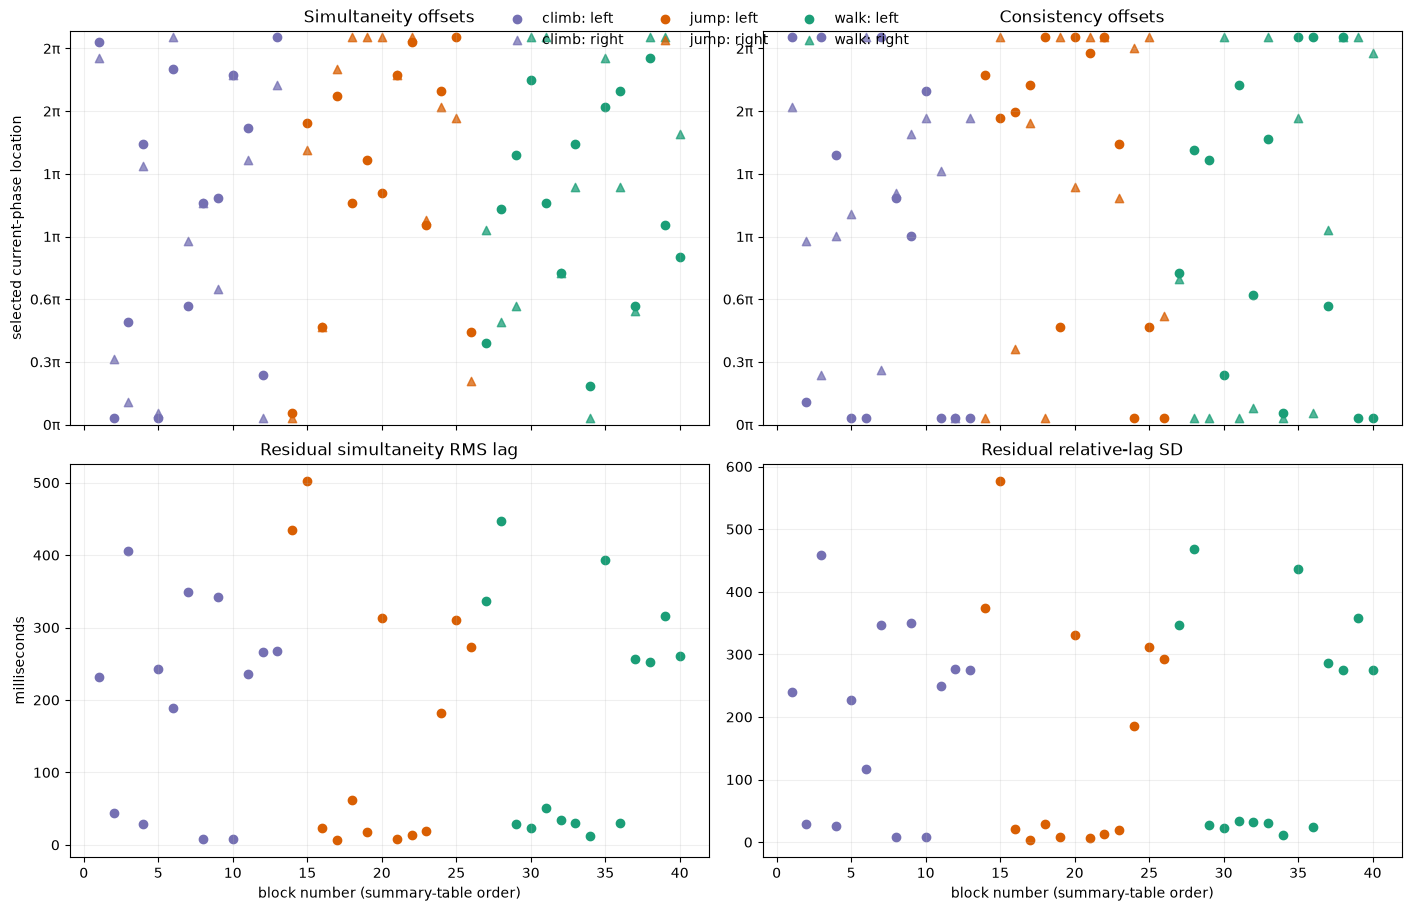

n_matched_cycles                current_rms_lag_ms         \
                          count median min max              count median   
skill day part                                                             
climb 1   s                   7    8.0   4  14                  7  246.0   
      3   e                   6   11.5   8  14                  6  268.1   
jump  1   s                   6    4.5   4   5                  6  338.6   
      3   e                   7    7.0   5  14                  7  192.2   
walk  1   s                   9    6.0   4  15                  9  312.0   
      3   e                   5    5.0   4   6                  5  282.8   

                             current_lag_sd_ms         ...  \
                  min    max             count median  ...   
skill day part                                         ...   
climb 1   s      70.3  454.0                 7  255.8  ...   
      3   e      13.6  403.7                 6  269.4  ...   
jump  1   s      44.7  616.7                 6  184.4  ...   
      3   e      18.4  422.5                 7  195.0  ...   
walk  1   s      55.3  524.3                 9  143.0  ...   
      3   e     117.3  461.0                 5  298.8  ...   

               consistent_lag_sd_ms        sync_5ms_basin_pct              \
                                min    max              count median  min   
skill day part                                                              
climb 1   s                    25.4  459.2                  7    0.6  0.3   
      3   e                     7.8  350.4                  6    3.9  1.1   
jump  1   s                     4.1  576.2                  6    0.3  0.2   
      3   e                     7.0  330.7                  7    2.7  1.4   
walk  1   s                    11.5  468.1                  9    1.4  0.1   
      3   e                    24.2  357.6                  5    1.5  1.3   

                    consistent_5ms_basin_pct                     
                max                    count median   min   max  
skill day part                                                   
climb 1   s     9.6                        7    2.4   0.4   9.1  
      3   e     7.7                        6   22.3  16.9  42.5  
jump  1   s     7.8                        6    3.6   0.6  33.6  
      3   e     5.5                        7   15.4   9.0  51.3  
walk  1   s     6.6                        9   11.1   1.8  87.9  
      3   e     9.2                        5    3.7   1.1  18.5  

[6 rows x 28 columns]

In [4]:
ok = summary[summary.fit_ok].copy()
ok["block_number"] = np.arange(1, len(ok) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, constrained_layout=True)
for skill, group in ok.groupby("skill", sort=False):
    color = P.SKILL_COLORS[skill]
    x = group["block_number"]
    axes[0, 0].scatter(x, group["sync_q_left_rad"], color=color, marker="o", label=f"{skill}: left")
    axes[0, 0].scatter(x, group["sync_q_right_rad"], color=color, marker="^", alpha=.75, label=f"{skill}: right")
    axes[0, 1].scatter(x, group["consistent_q_left_rad"], color=color, marker="o", label=f"{skill}: left")
    axes[0, 1].scatter(x, group["consistent_q_right_rad"], color=color, marker="^", alpha=.75, label=f"{skill}: right")
    axes[1, 0].scatter(x, group["sync_rms_lag_ms"], color=color, label=skill)
    axes[1, 1].scatter(x, group["consistent_lag_sd_ms"], color=color, label=skill)
for ax in axes[0]:
    ax.set_ylim(0, 2*np.pi)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x / np.pi:.1g}π"))
for ax, title in zip(axes.flat, [
    "Simultaneity offsets", "Consistency offsets",
    "Residual simultaneity RMS lag", "Residual relative-lag SD",
]):
    ax.set_title(title)
    ax.grid(alpha=.2)
axes[0, 0].set_ylabel("selected current-phase location")
axes[1, 0].set_ylabel("milliseconds")
for ax in axes[1]:
    ax.set_xlabel("block number (summary-table order)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[:6], labels[:6], loc="upper center", ncol=3, frameon=False)
plt.show()

display(ok.groupby(["skill", "day", "part"])[[
    "n_matched_cycles", "current_rms_lag_ms", "current_lag_sd_ms",
    "sync_rms_lag_ms", "consistent_lag_sd_ms",
    "sync_5ms_basin_pct", "consistent_5ms_basin_pct",
]].agg(["count", "median", "min", "max"]).round(1))

## Detailed landscapes and changed average cycles

For the longest block of every movement/day/part condition, the heat maps show
whether the selected offsets are isolated minima or broad ridges. The average
cycle plots show how rephasing changes the raw root-relative 3-D hand paths.
A filled dot is the selected zero event. Both means and SDs use **only the
matched cycles used in the timing objective**. The lower x-axis is left's
rephased coordinate, with its reference at zero. The upper x-axis is right's
own rephased coordinate. Right's curve is translated so that its reference is
located at the circular-mean left-phase location where that right event occurs;
it is not forced to zero. The right mean and SD are wrapped across their
boundary using adjacent periodic copies, so every panel retains the full left
cycle from 0 to 2π after translation. The orange vertical band is its
across-cycle plus or minus one SD in left-phase units, while the trace bands
are plus or minus one SD in root-relative y. Set `SHOW_ALL_BLOCK_DETAILS = True` to render the same
diagnostic for every usable block; the table already reports all blocks.
Because phase is circular, a red star on a heat-map edge denotes an event close
to the current zero; consult the signed-offset table columns rather than
interpreting it as a distant endpoint.

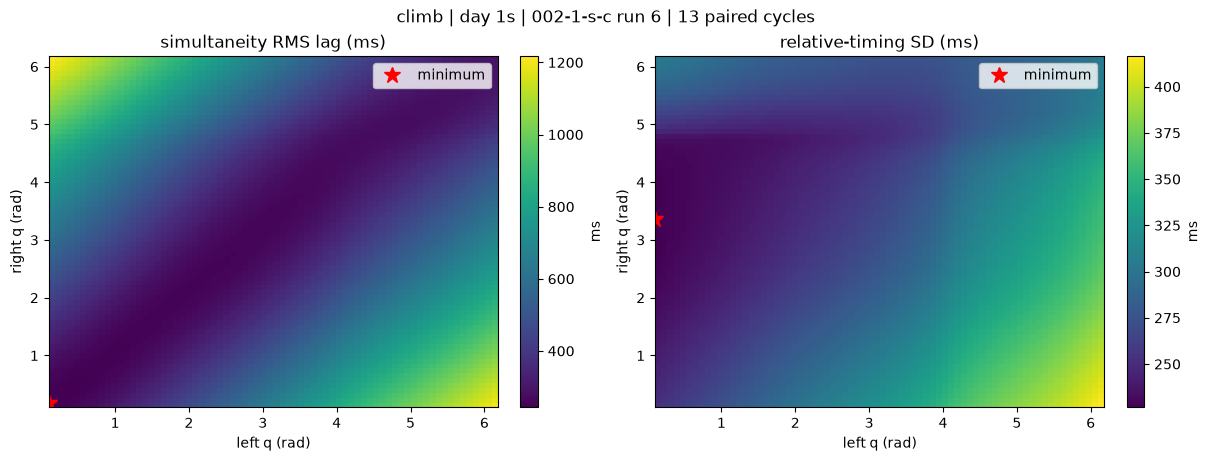

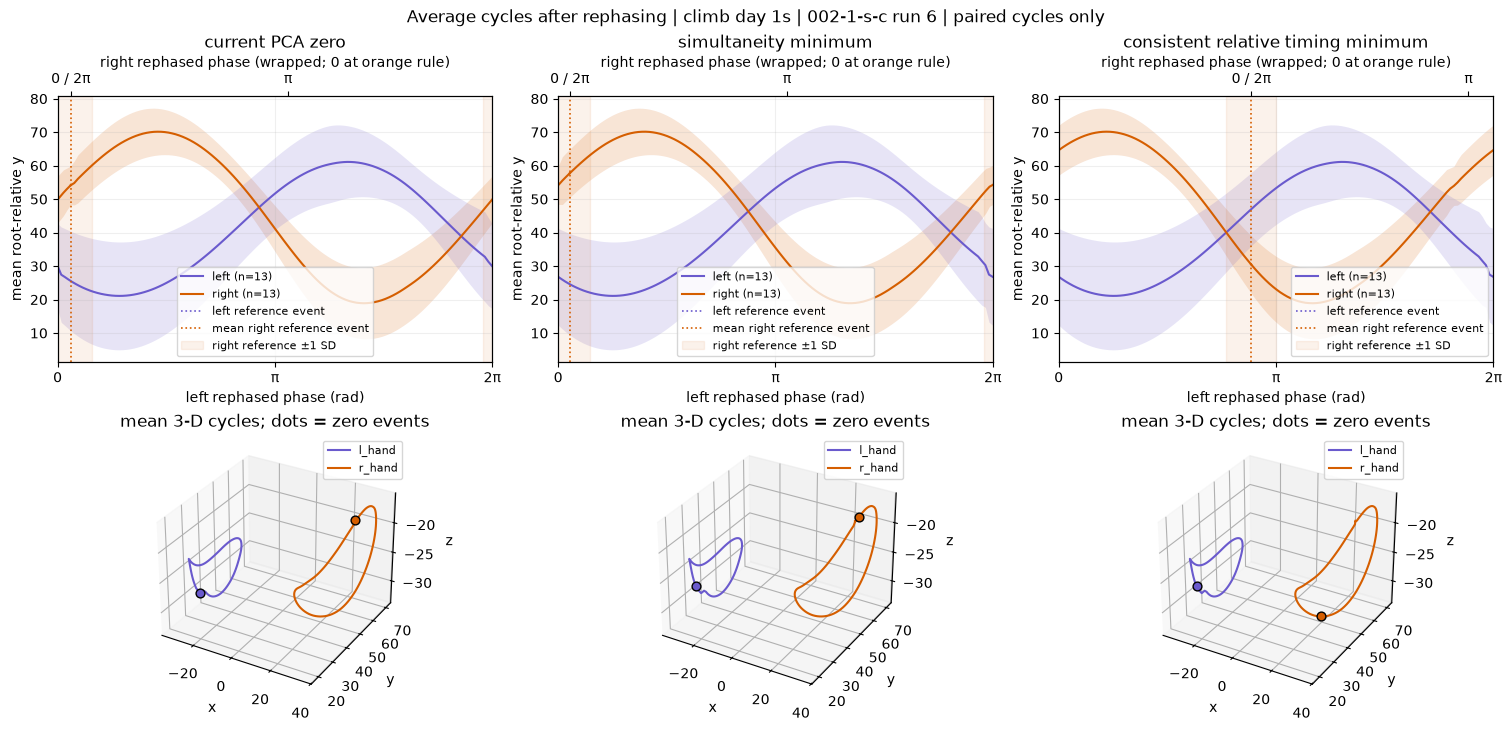

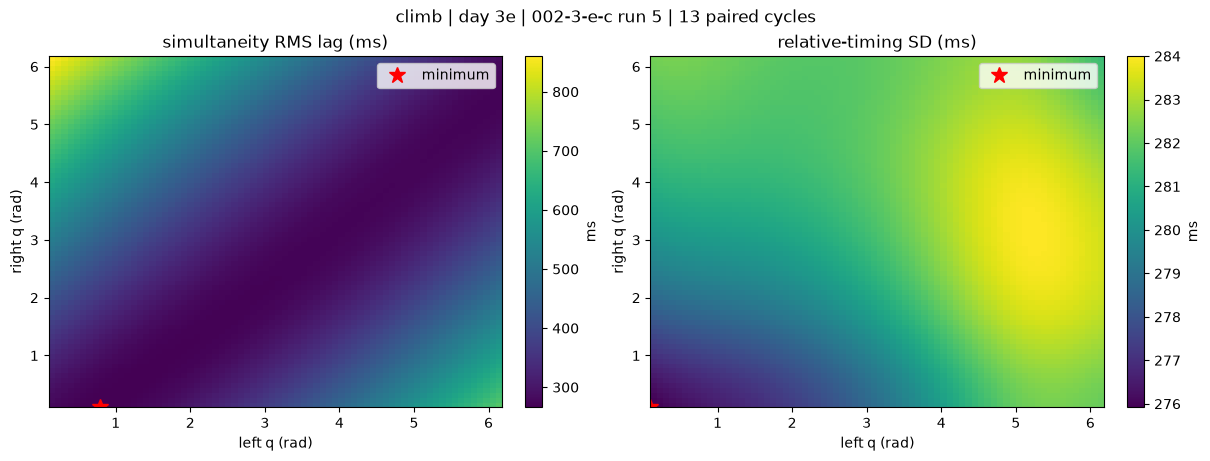

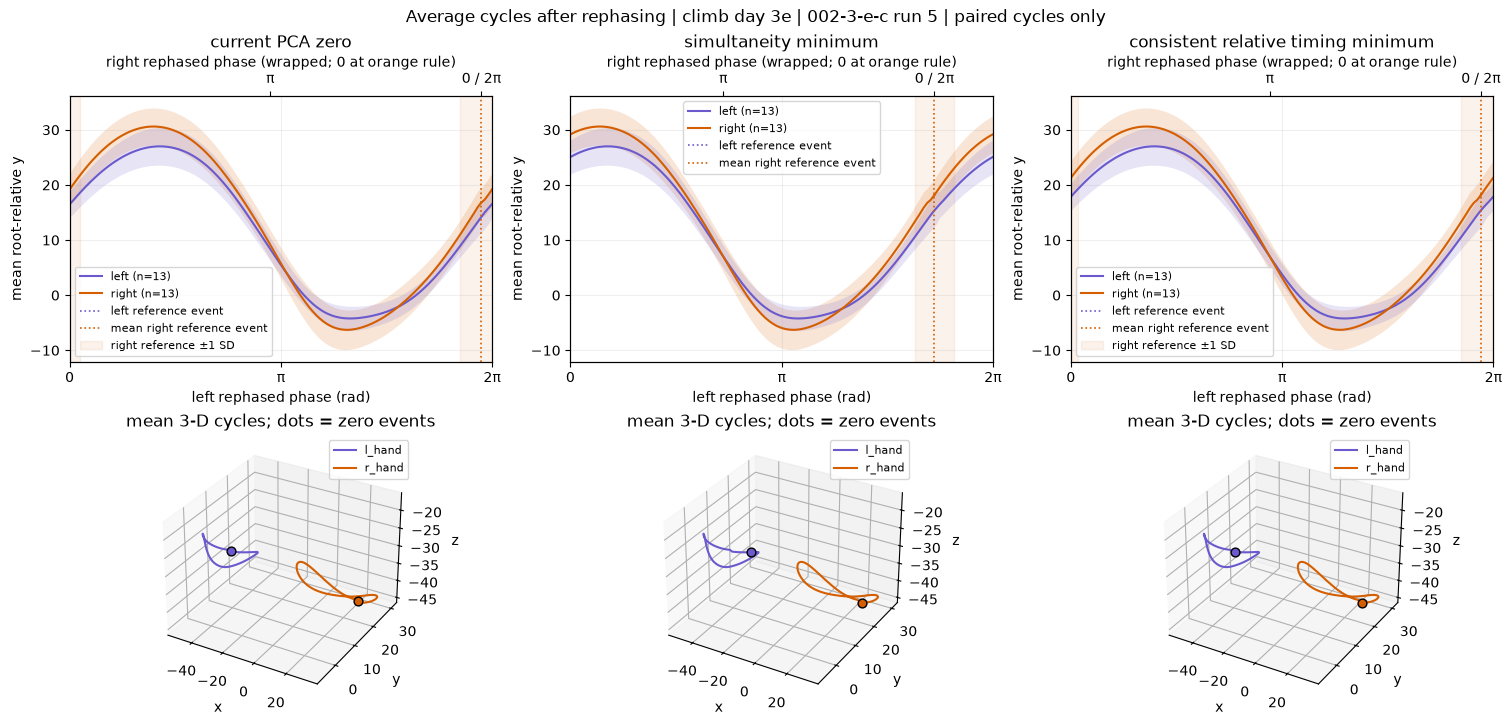

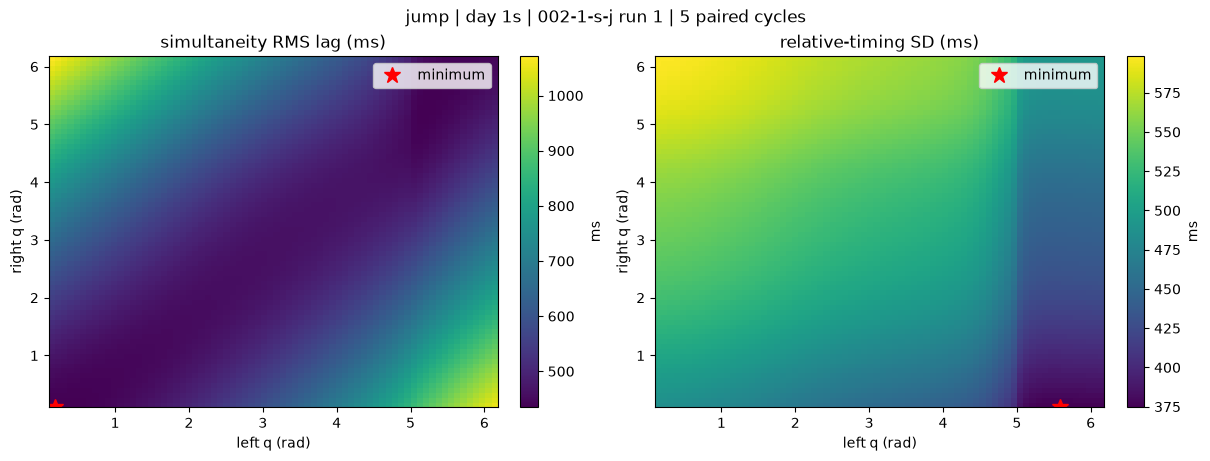

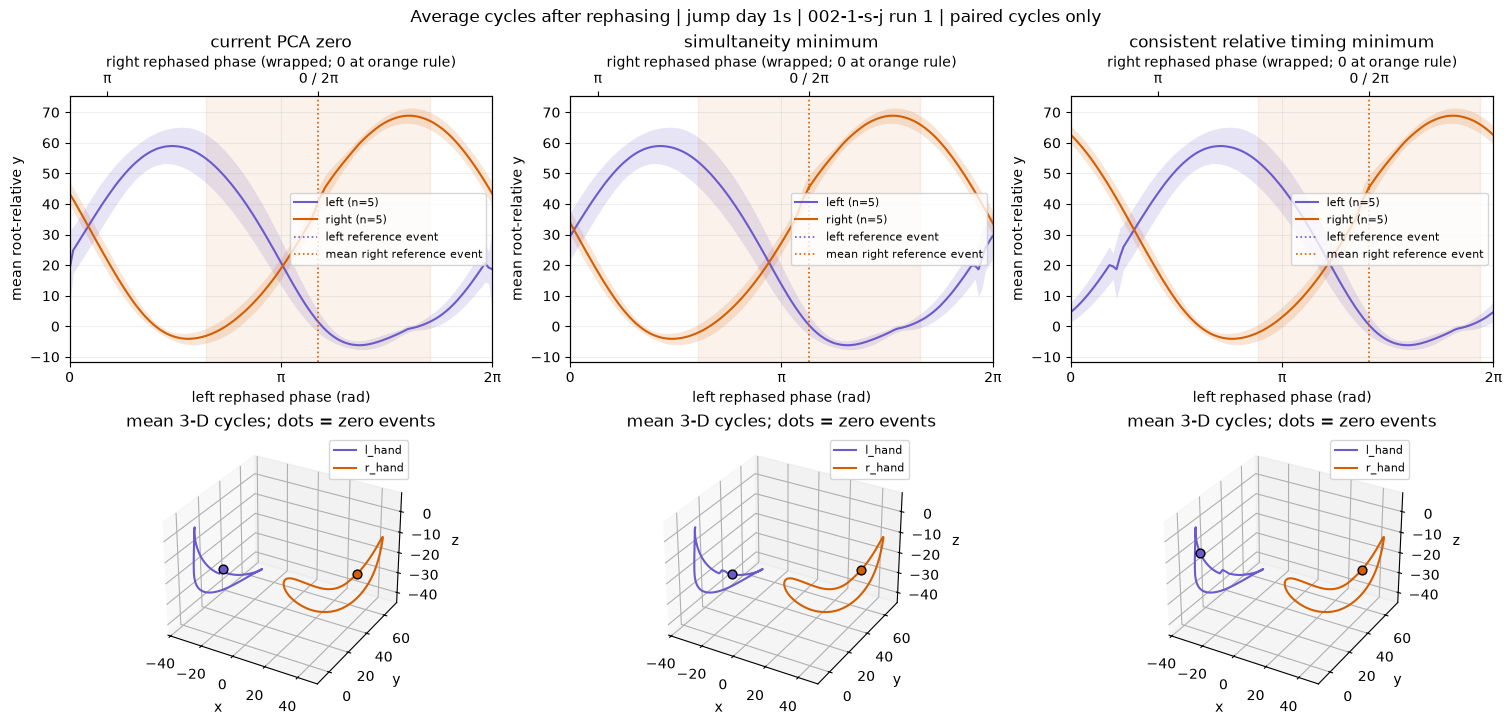

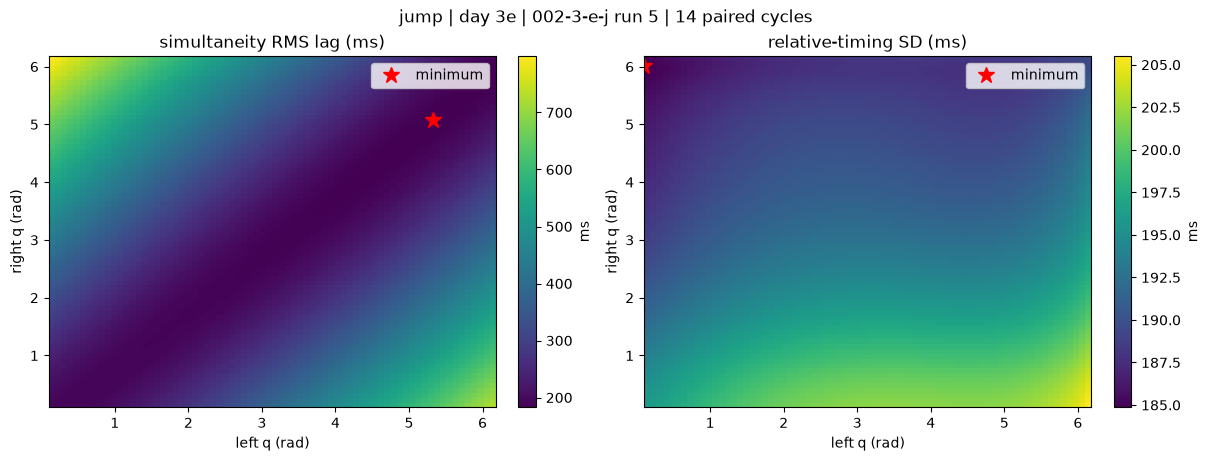

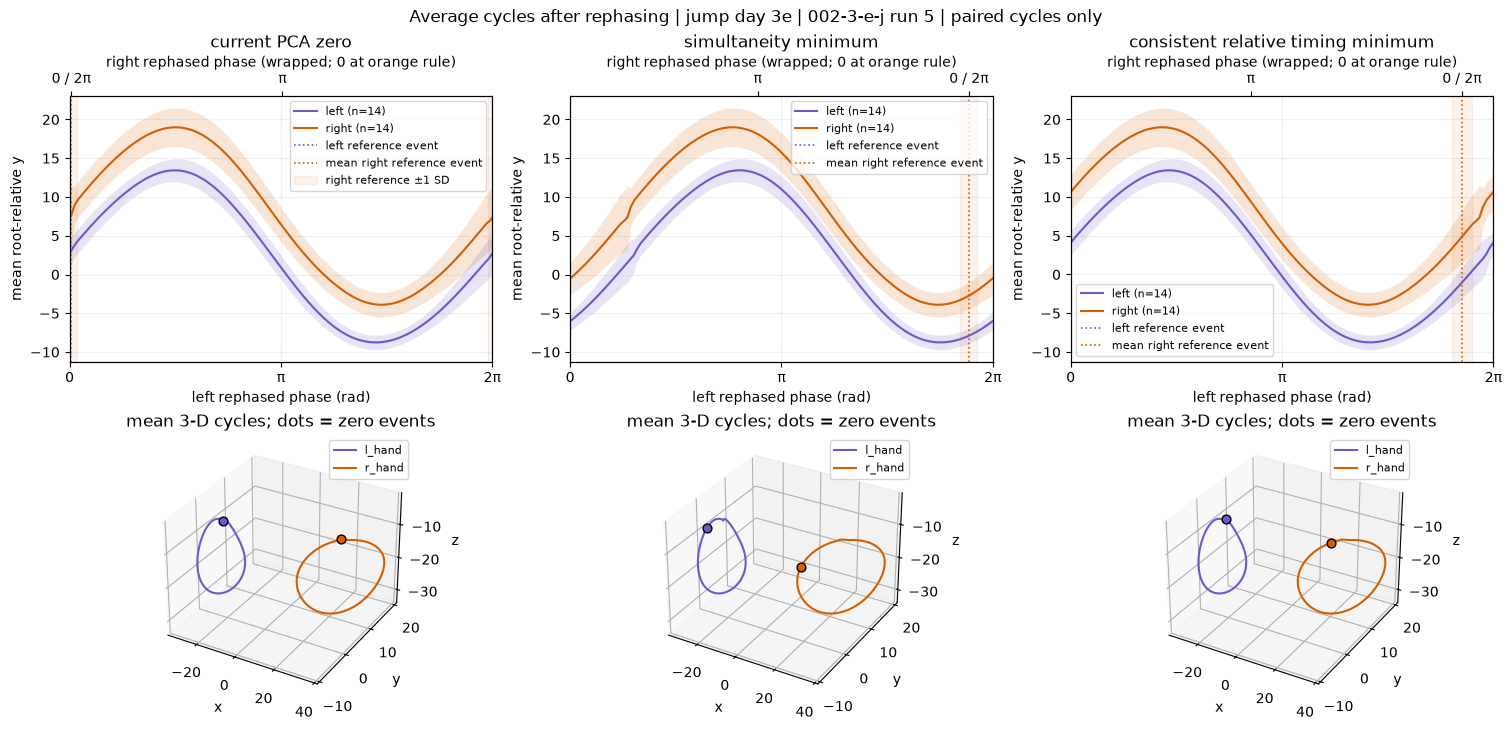

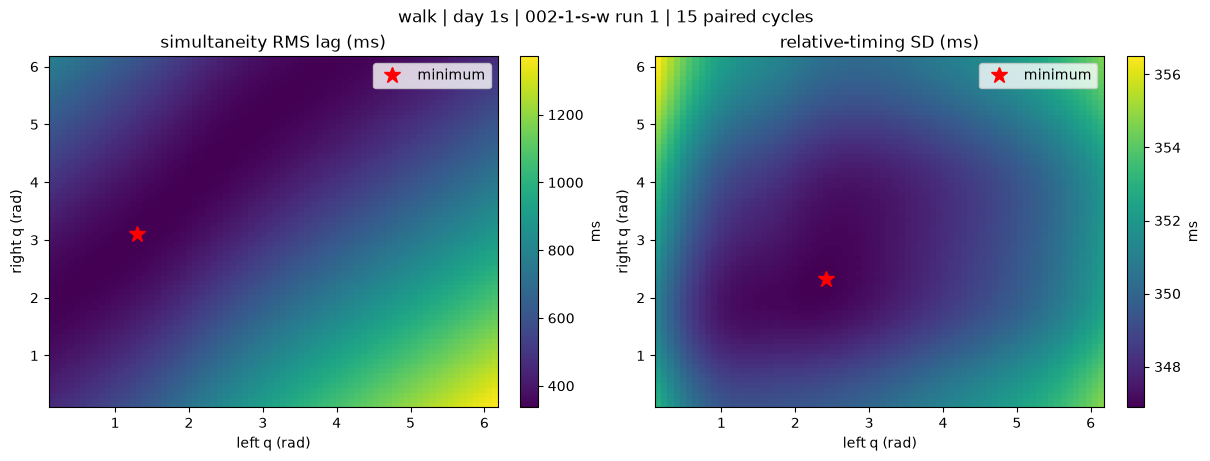

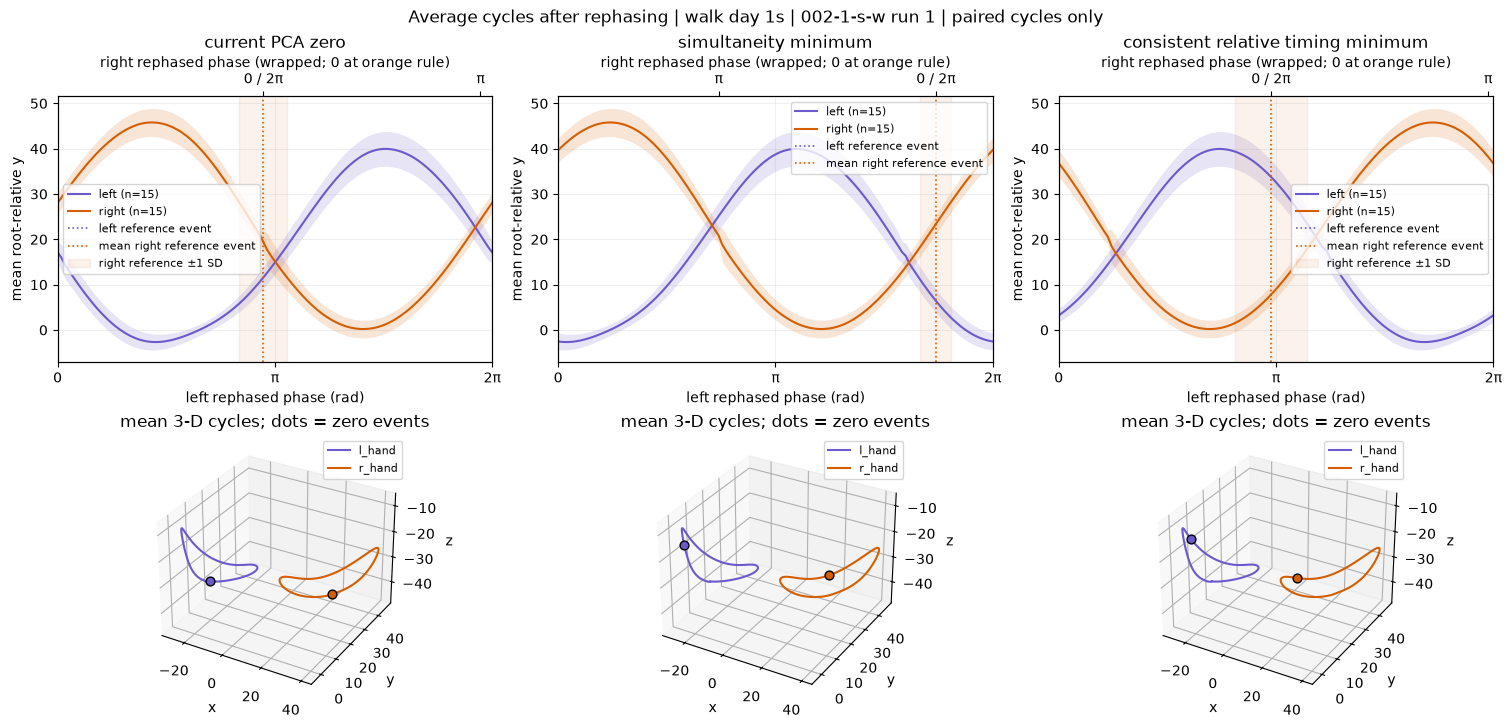

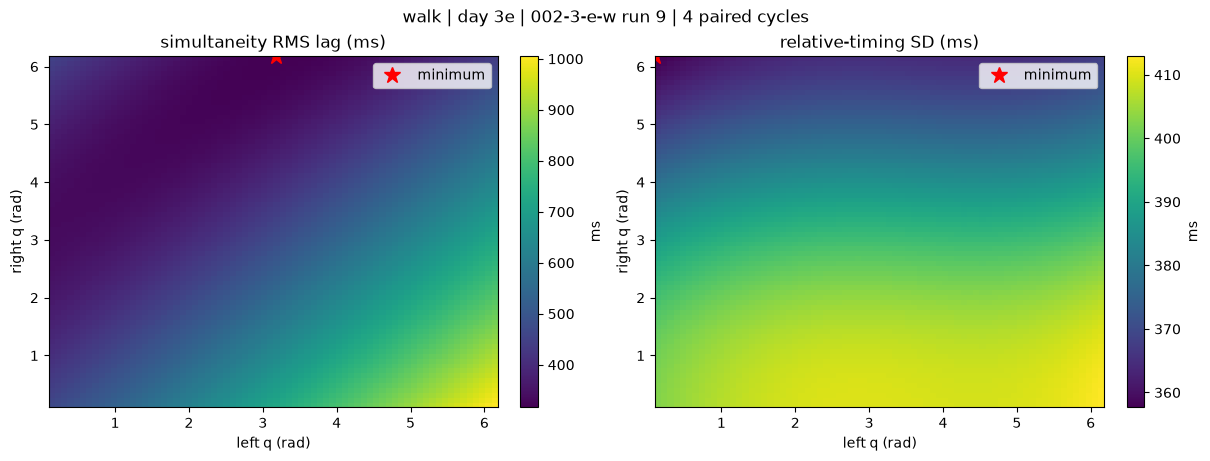

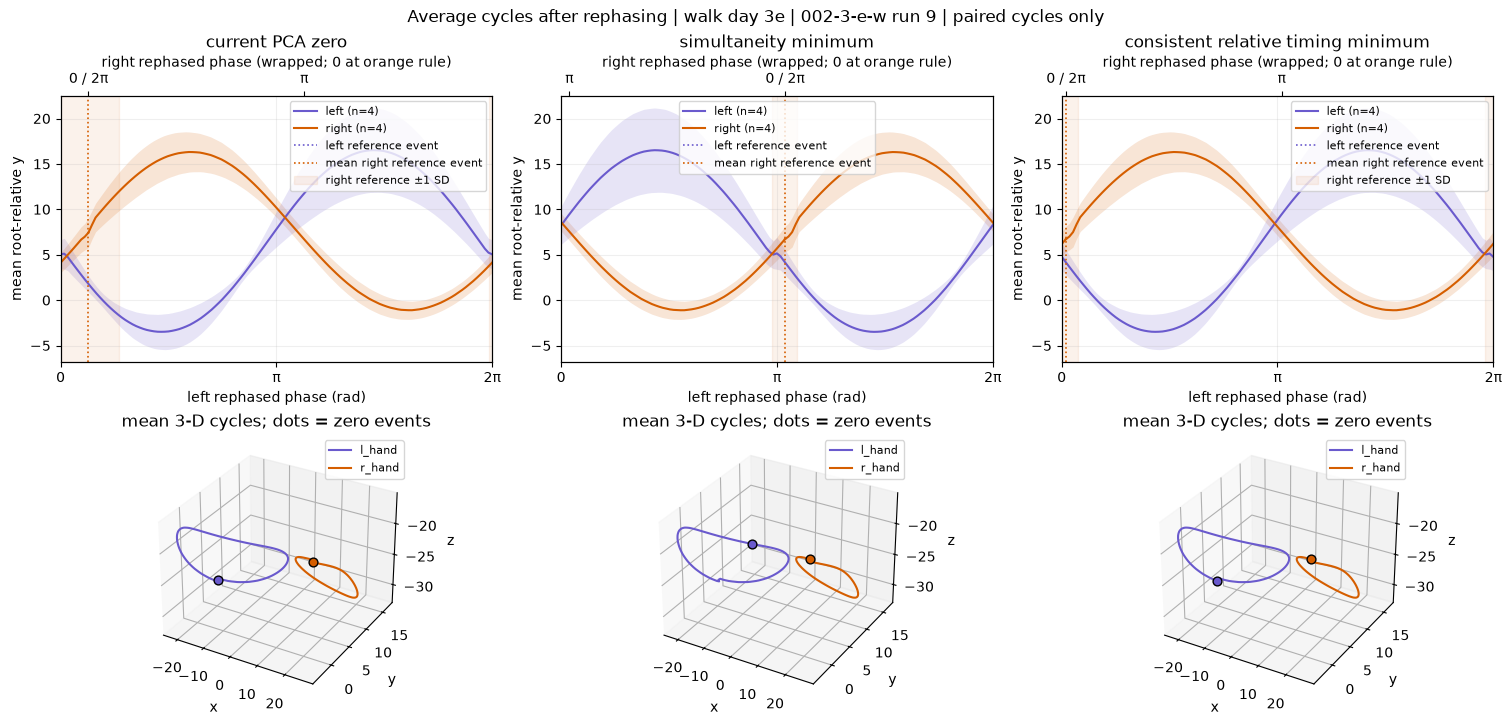

In [5]:
SHOW_ALL_BLOCK_DETAILS = False


def raw_hand_trajectory(meta, hand):
    runs = L.list_available_blocks(subject=meta["subject"])
    match = runs[
        (runs["day"] == meta["day"]) & (runs["part"] == meta["part"]) &
        (runs["skill"] == meta["skill"]) & (runs["source_file"] == meta["source_file"]) &
        (runs["movement_run_id"] == meta["movement_run_id"])
    ]
    if len(match) != 1:
        raise ValueError(f"Could not resolve one raw block for {meta}")
    row = match.iloc[0]
    pos = L.load_position_file(row["path"])
    seg = pos.iloc[int(row["run_start"]):int(row["run_end"])]
    hand_cols = [f"{hand}.x", f"{hand}.y", f"{hand}.z"]
    root_cols = ["root.x", "root.y", "root.z"]
    return seg[hand_cols].to_numpy(float) - seg[root_cols].to_numpy(float)


def paired_mean_cycle(X, samples, pairs, hand_index, phase_offset, grid=np.linspace(0, 2*np.pi, 121)):
    """Mean and SD raw XYZ cycle from exactly the paired cycles used above."""
    regridded = []
    groups = {int(cycle): group for cycle, group in samples.groupby("cycle", sort=True)}
    for pair in pairs:
        cycle = pair[hand_index]["cycle"]
        group = groups[cycle]
        index = group["sample_index"].to_numpy(int)
        q = group["phase_in_cycle"].to_numpy(float)
        valid = np.isfinite(q) & (index >= 0) & (index < len(X))
        if valid.sum() < 5:
            continue
        q, values = np.mod(q[valid] - phase_offset, 2*np.pi), X[index[valid]]
        order = np.argsort(q)
        q, values = q[order], values[order]
        if q[0] > .25 or q[-1] < 2*np.pi - .25:
            continue
        q_extended = np.r_[q[-1] - 2*np.pi, q, q[0] + 2*np.pi]
        v_extended = np.vstack([values[-1], values, values[0]])
        regridded.append(np.column_stack([
            np.interp(grid, q_extended, v_extended[:, axis]) for axis in range(3)
        ]))
    regridded = np.asarray(regridded)
    mean = np.nanmean(regridded, axis=0)
    sd = np.nanstd(regridded, axis=0)
    # A periodic copy supplies the adjacent-cycle portion when a trace is
    # shifted on the shared left-phase display axis. Make the seam exact.
    mean[-1] = mean[0]
    sd[-1] = sd[0]
    return grid, mean, sd, len(regridded)


def plot_wrapped_mean_and_sd(ax, q, mean, sd, shift, color, label):
    """Draw periodic copies of one mean cycle inside a 0..2pi display window."""
    for wrap in (-2*np.pi, 0., 2*np.pi):
        x = q + shift + wrap
        ax.plot(x, mean[:, 1], color=color, label=label if wrap == 0 else None)
        ax.fill_between(x, mean[:, 1] - sd[:, 1], mean[:, 1] + sd[:, 1],
                        color=color, alpha=.16, linewidth=0)


def plot_details(key):
    record, results = alignment[key], by_block[key]
    meta = results["l_hand"]["meta"]
    n = len(record["pairs"])
    surfaces = [
        (np.sqrt(record["ss_sync"] / n) * 1000, record["sync_indices"], "simultaneity RMS lag (ms)"),
        (np.sqrt(record["ss_consistent"] / (n - 1)) * 1000, record["consistent_indices"], "relative-timing SD (ms)"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    for ax, (surface, (i, j), title) in zip(axes, surfaces):
        im = ax.imshow(surface.T, origin="lower", aspect="auto",
                       extent=[PHASE_GRID[0], PHASE_GRID[-1], PHASE_GRID[0], PHASE_GRID[-1]],
                       cmap="viridis")
        ax.plot(PHASE_GRID[i], PHASE_GRID[j], "r*", ms=12, label="minimum")
        ax.set(xlabel="left q (rad)", ylabel="right q (rad)", title=title)
        ax.legend(loc="upper right")
        fig.colorbar(im, ax=ax, label="ms")
    fig.suptitle(f"{meta['skill']} | day {meta['day']}{meta['part']} | "
                 f"{meta['source_file']} run {meta['movement_run_id']} | {n} paired cycles")
    plt.show()

    X_left = raw_hand_trajectory(meta, "l_hand")
    X_right = raw_hand_trajectory(meta, "r_hand")
    configurations = [
        ("current PCA zero", 0., 0.),
        ("simultaneity minimum", PHASE_GRID[record["sync_indices"][0]],
         PHASE_GRID[record["sync_indices"][1]]),
        ("consistent relative timing minimum", PHASE_GRID[record["consistent_indices"][0]],
         PHASE_GRID[record["consistent_indices"][1]]),
    ]
    fig = plt.figure(figsize=(15, 7), constrained_layout=True)
    for col, (title, left_q, right_q) in enumerate(configurations):
        # Each hand is rephased around its OWN reference point before it is
        # averaged. The right curve is then translated (not rephased again)
        # by where its reference falls in left phase across paired cycles.
        right_shift, right_shift_sd, n_registered = right_reference_location_in_left_phase(
            record["pairs"], left_q, right_q
        )
        q, left, left_sd, n_left = paired_mean_cycle(
            X_left, results["l_hand"]["samples"], record["pairs"], 0, left_q
        )
        _, right, right_sd, n_right = paired_mean_cycle(
            X_right, results["r_hand"]["samples"], record["pairs"], 1, right_q
        )
        right_reference_x = np.mod(right_shift, 2*np.pi)
        ax = fig.add_subplot(2, 3, col + 1)
        ax.plot(q, left[:, 1], color=P.HAND_COLORS["l_hand"], label=f"left (n={n_left})")
        plot_wrapped_mean_and_sd(ax, q, right, right_sd, right_shift,
                                 P.HAND_COLORS["r_hand"], f"right (n={n_right})")
        ax.fill_between(q, left[:, 1] - left_sd[:, 1], left[:, 1] + left_sd[:, 1],
                        color=P.HAND_COLORS["l_hand"], alpha=.16, linewidth=0)
        ax.axvline(0, color=P.HAND_COLORS["l_hand"], ls=":", lw=1.2, label="left reference event")
        ax.axvline(right_reference_x, color=P.HAND_COLORS["r_hand"], ls=":", lw=1.2,
                   label="mean right reference event")
        for wrap in (-2*np.pi, 0., 2*np.pi):
            x = right_shift + wrap
            if -right_shift_sd < x < 2*np.pi + right_shift_sd:
                ax.axvspan(x - right_shift_sd, x + right_shift_sd,
                           color=P.HAND_COLORS["r_hand"], alpha=.08,
                           label="right reference ±1 SD" if wrap == 0 else None)
        ax.set(title=title, xlabel="left rephased phase (rad)",
               ylabel="mean root-relative y", xlim=(0, 2*np.pi))
        ax.set_xticks([0, np.pi, 2*np.pi], ["0", "π", "2π"])
        # A top axis carries right's own rephased phase. Its zero is located
        # at the observed mean relative phase, not artificially at x=0. It
        # wraps at that rule because the displayed right mean is periodic.
        right_axis = ax.twiny()
        right_axis.set_xlim(0, 2*np.pi)
        right_axis.set_xticks([right_reference_x, np.mod(right_reference_x + np.pi, 2*np.pi)], ["0 / 2π", "π"])
        right_axis.set_xlabel("right rephased phase (wrapped; 0 at orange rule)")
        ax.grid(alpha=.2); ax.legend(fontsize=8)
        ax3 = fig.add_subplot(2, 3, col + 4, projection="3d")
        for values, zero_i, hand in [(left, 0, "l_hand"), (right, 0, "r_hand")]:
            color = P.HAND_COLORS[hand]
            ax3.plot(values[:, 0], values[:, 1], values[:, 2], color=color, label=hand)
            ax3.scatter(*values[zero_i], color=color, s=40, edgecolor="black")
        ax3.set(xlabel="x", ylabel="y", zlabel="z", title="mean 3-D cycles; dots = zero events")
        ax3.legend(fontsize=8)
    fig.suptitle(f"Average cycles after rephasing | {meta['skill']} day {meta['day']}{meta['part']} | "
                 f"{meta['source_file']} run {meta['movement_run_id']} | paired cycles only")
    plt.show()


if SHOW_ALL_BLOCK_DETAILS:
    detail_keys = list(alignment)
else:
    detail_keys = []
    for _, condition in ok.groupby(["skill", "day", "part"]):
        row = condition.loc[condition["run_duration_sec"].idxmax()]
        detail_keys.append((row.subject, int(row.day), row.part, row.skill,
                            row.source_file, int(row.movement_run_id)))

for key in detail_keys:
    plot_details(key)

## What else would help decide which definition captures the data?

The notebook makes the fitted offsets, residual timing, objective landscapes,
and altered average cycles visible. Before selecting a convention, the most
valuable next checks would be:

- **Held-out-cycle validation:** fit offsets on alternating/early cycles and
  score both objectives on held-out cycles. This distinguishes a reproducible
  landmark from a fitting accident.
- **Minimum sharpness:** report the area within a practical tolerance (for
  example 5 ms) of the minimum. A broad ridge means the exact reported offset
  is not well identified.
- **Movement context:** overlay the selected times on raw y, speed,
  acceleration, and video/game events if available. Low timing variation alone
  does not establish anatomical meaning.
- **Phase reliability:** compare Hilbert amplitude, local phase velocity, and
  excluded-cycle counts at candidate landmarks. A timing optimum may be
  fragile if it relies on weak phase estimates.
- **More markers:** extend the pairwise objective to reliable marker sets,
  preferably with uncertainty/reliability weights. This tests whether a
  hand-derived landmark represents a whole-body event.
- **Interpret stable nonzero delays carefully:** a low consistency SD with a
  substantial mean lag is evidence for a repeatable lead/lag, not necessarily
  an error to erase.

Use the **simultaneity** minimum when phase zero should mean a shared instant.
Use the **consistency** minimum when it should mean a maximally repeatable
relationship, even if one hand systematically leads. Neither criterion alone
is a biological ground truth; this notebook supplies a transparent timing
criterion to evaluate alongside the trajectory plots and domain context.